In [10]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from pathlib import Path
import plotly.express as px

In [ ]:
## import CO2 data over 20+ years

In [26]:
CO2_data = pd.read_csv('C02_gdp_2.csv')
CO2_data = CO2_data.drop(columns = ['Unnamed: 0'])
print(CO2_data.head())

       Country  Year     Total      Coal       Oil       Gas    Cement  \
0  Afghanistan  1981  1.978463  0.333424  1.014928  0.304112  0.032879   
1  Afghanistan  2002  1.051609  0.054960  0.439680  0.545936  0.011033   
2  Afghanistan  2003  1.185951  0.091600  0.619216  0.465328  0.009807   
3  Afghanistan  2004  0.889167  0.091600  0.560592  0.227168  0.009807   
4  Afghanistan  2005  1.303267  0.106256  0.861040  0.329760  0.006211   

   Flaring  Other  Per Capita  High Emissions Country Code           GDP  
0  0.29312    0.0    0.150206           False          AFG  3.478788e+09  
1  0.00000    0.0    0.046530           False          AFG  4.055180e+09  
2  0.00000    0.0    0.050081           False          AFG  4.515559e+09  
3  0.00000    0.0    0.035960           False          AFG  5.226779e+09  
4  0.00000    0.0    0.050801           False          AFG  6.209138e+09  


### some feature engineering

In [27]:
CO2_data = CO2_data.sort_values('Year', ascending=True)
CO2_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6370 entries, 0 to 6369
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country         6370 non-null   object 
 1   Year            6370 non-null   int64  
 2   Total           6370 non-null   float64
 3   Coal            6370 non-null   float64
 4   Oil             6370 non-null   float64
 5   Gas             6370 non-null   float64
 6   Cement          6370 non-null   float64
 7   Flaring         6370 non-null   float64
 8   Other           6370 non-null   float64
 9   Per Capita      6370 non-null   float64
 10  High Emissions  6370 non-null   bool   
 11  Country Code    6370 non-null   object 
 12  GDP             6370 non-null   float64
dtypes: bool(1), float64(9), int64(1), object(2)
memory usage: 653.2+ KB


In [48]:
grouped = CO2_data[['Coal', 'Year', 'Country Code', 'Country']]
grouped = grouped.sort_values(by = ['Country Code', 'Country', 'Year'])
grouped['pct'] = grouped.groupby(['Country Code', 'Country'])['Coal'].pct_change() + 1
grouped = grouped.fillna(0)
grouped.replace([np.inf, -np.inf], 0, inplace=True)
grouped.head()
grouped.describe()

,Coal,Year,pct
count,6370.000000,6370.000000,6370.000000
mean,59.314812,2001.508006,0.661859
std,399.035639,11.310711,1.338573
min,0.000000,1981.000000,0.000000
25%,0.000000,1992.000000,0.000000
50%,0.087936,2002.000000,0.829445
75%,6.695074,2011.000000,1.019376
max,7493.454393,2020.000000,63.000000


In [49]:
grouped = grouped.sort_values('Year', ascending=True)

### Plot Choropleth - dynamic over time

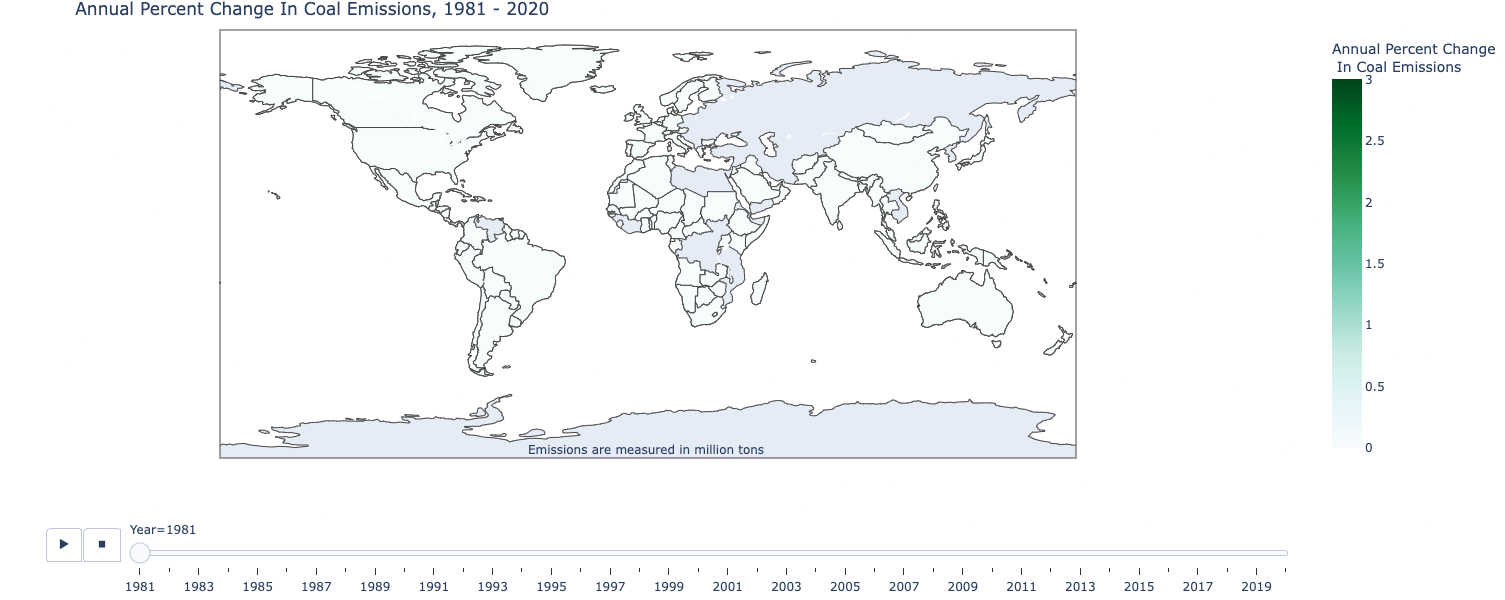

In [57]:
fig = px.choropleth(grouped, locations="Country Code", color="pct", hover_name="Country", 
                    hover_data = ['Coal'], animation_frame="Year",
                    color_continuous_scale="BuGn", width=1000, height=600, range_color=[0, 3])
fig.update_layout(
    margin={"r":0,"t":30,"l":0,"b":5},
    coloraxis_colorbar={
        'title':'Annual Percent Change<br> In Coal Emissions'})

##
    
fig.update_layout(
    title_text='Annual Percent Change In Coal Emissions, 1981 - 2020',
    annotations = [dict(
        x=0.5,
        y=0,    #Trying a negative number makes the caption disappear - I'd like the caption to be below the map
        xref='paper',
        yref='paper',
        text='Emissions are measured in million tons ',
        showarrow = False
    )]
)
##
fig.show()

In [58]:
fig.write_html('dynamic_map.html')

### EDA on emissions from each source of energy generation, by country

In [36]:
subset = ['USA', 'India', 'Norway', 'Malaysia', 'Nigeria', 'Mexico', 
          'Kenya', 'China', 'Bolivia', 'Japan', 'Thailand' ]

In [37]:
data_subset = CO2_data[CO2_data['Country'].isin(subset)]

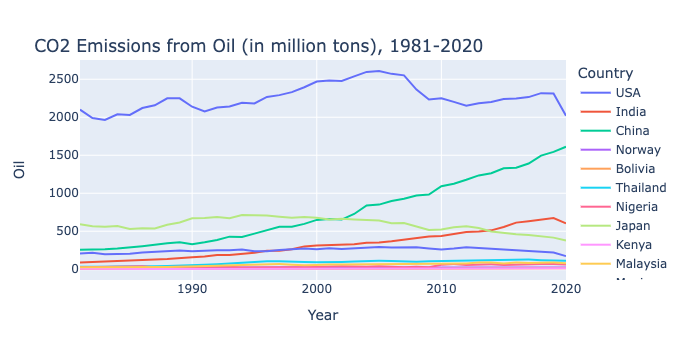

In [39]:
fig=px.line(data_subset, x='Year', y='Oil', color='Country')

fig.update_layout(
    title_text='<br>CO2 Emissions from Oil (in million tons), 1981-2020',
    annotations = [dict(
        x=0.5,
        y=-0.3,    
        xref='paper',
        yref='paper',
        text='',
        showarrow = False
    )]
)

fig.show()

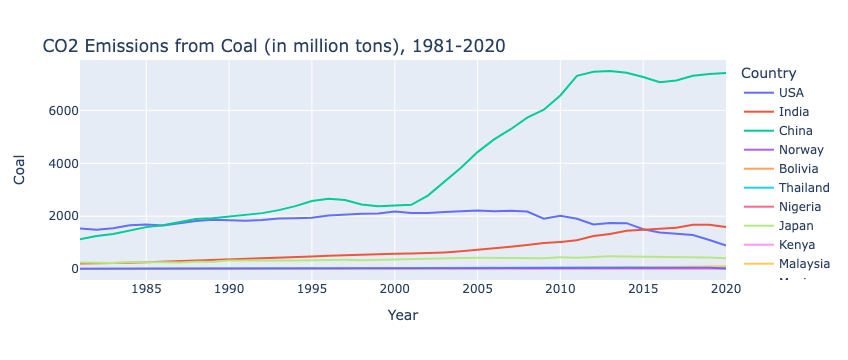

In [42]:
fig=px.line(data_subset, x='Year', y='Coal', color='Country')

fig.update_layout(
    title_text='<br>CO2 Emissions from Coal (in million tons), 1981-2020',
    annotations = [dict(
        x=0.5,
        y=-0.3,    
        xref='paper',
        yref='paper',
        text='',
        showarrow = False
    )]
)
fig.show()

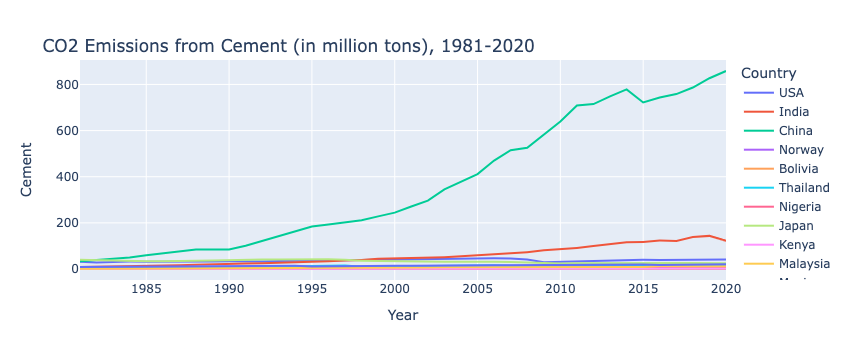

In [44]:
fig=px.line(data_subset, x='Year', y='Cement', color='Country')

fig.update_layout(
    title_text='<br>CO2 Emissions from Cement (in million tons), 1981-2020',
    annotations = [dict(
        x=0.5,
        y=-0.3,    
        xref='paper',
        yref='paper',
        text='',
        showarrow = False
    )]
)
fig.show()

In [45]:
fig.write_html('px_line_dynamic.html')